In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px



In [2]:
df = pd.read_csv("Supplement_Sales_Weekly_Expanded.csv")
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


In [3]:
df.shape

(4384, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4384 non-null   object 
 1   Product Name    4384 non-null   object 
 2   Category        4384 non-null   object 
 3   Units Sold      4384 non-null   int64  
 4   Price           4384 non-null   float64
 5   Revenue         4384 non-null   float64
 6   Discount        4384 non-null   float64
 7   Units Returned  4384 non-null   int64  
 8   Location        4384 non-null   object 
 9   Platform        4384 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 342.6+ KB


In [5]:
df.isnull().sum()

Date              0
Product Name      0
Category          0
Units Sold        0
Price             0
Revenue           0
Discount          0
Units Returned    0
Location          0
Platform          0
dtype: int64

In [7]:
df.duplicated

<bound method DataFrame.duplicated of             Date        Product Name     Category  Units Sold  Price  Revenue  \
0     2020-01-06        Whey Protein      Protein         143  31.98  4573.14   
1     2020-01-06           Vitamin C      Vitamin         139  42.51  5908.89   
2     2020-01-06            Fish Oil        Omega         161  12.91  2078.51   
3     2020-01-06        Multivitamin      Vitamin         140  16.07  2249.80   
4     2020-01-06         Pre-Workout  Performance         157  35.47  5568.79   
...          ...                 ...          ...         ...    ...      ...   
4379  2025-03-31           Melatonin    Sleep Aid         160  47.79  7646.40   
4380  2025-03-31              Biotin      Vitamin         154  38.12  5870.48   
4381  2025-03-31   Green Tea Extract   Fat Burner         139  20.40  2835.60   
4382  2025-03-31     Iron Supplement      Mineral         154  18.31  2819.74   
4383  2025-03-31  Electrolyte Powder    Hydration         178  39.12  6

In [8]:
df.describe()

,Units Sold,Price,Revenue,Discount,Units Returned
count,4384.000000,4384.000000,4384.000000,4384.000000,4384.000000
mean,150.200274,34.781229,5226.569446,0.124398,1.531478
std,12.396099,14.198309,2192.491946,0.071792,1.258479
min,103.000000,10.000000,1284.000000,0.000000,0.000000
25%,142.000000,22.597500,3349.372500,0.060000,1.000000
50%,150.000000,34.720000,5173.140000,0.120000,1.000000
75%,158.000000,46.712500,7009.960000,0.190000,2.000000
max,194.000000,59.970000,10761.850000,0.250000,8.000000


In [9]:
df.describe(include='object')

,Date,Product Name,Category,Location,Platform
count,4384,4384,4384,4384,4384
unique,274,16,10,3,3
top,2020-01-06,Whey Protein,Vitamin,Canada,iHerb
freq,16,274,822,1507,1499


In [10]:
import warnings
warnings.filterwarnings('ignore')

In [11]:
df.dtypes

Date               object
Product Name       object
Category           object
Units Sold          int64
Price             float64
Revenue           float64
Discount          float64
Units Returned      int64
Location           object
Platform           object
dtype: object

In [12]:
df['Date'] = pd.to_datetime(df['Date'])

In [13]:
df.dtypes

Date              datetime64[ns]
Product Name              object
Category                  object
Units Sold                 int64
Price                    float64
Revenue                  float64
Discount                 float64
Units Returned             int64
Location                  object
Platform                  object
dtype: object

In [15]:
df.columns

Index(['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue',
       'Discount', 'Units Returned', 'Location', 'Platform'],
      dtype='object')

In [19]:
daily_sales = df.groupby('Date').agg({
    "Revenue": "sum",
    "Units Sold":"sum",
    "Units Returned":"sum"

    }).reset_index()

In [20]:
daily_sales

,Date,Revenue,Units Sold,Units Returned
0,2020-01-06,71848.56,2406,19
1,2020-01-13,72416.18,2374,27
2,2020-01-20,76152.42,2370,26
3,2020-01-27,70306.73,2397,29
4,2020-02-03,98011.64,2384,34
...,...,...,...,...
269,2025-03-03,66065.44,2431,36
270,2025-03-10,92509.57,2411,30
271,2025-03-17,65590.53,2381,22
272,2025-03-24,69778.44,2416,27


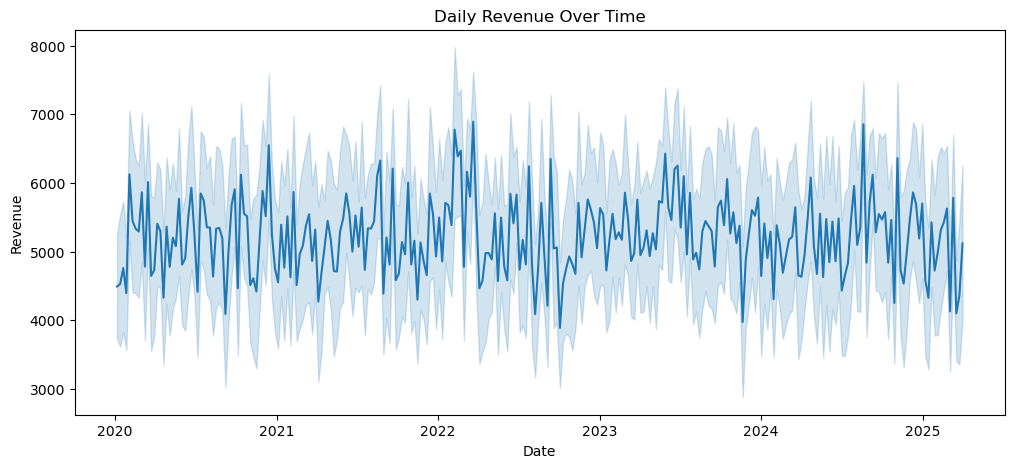

In [24]:
plt.figure(figsize=(12,5))
sns.lineplot(x="Date",y="Revenue",data=df)
plt.title("Daily Revenue Over Time")
plt.show()

In [36]:
CR = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

In [42]:
CR = CR

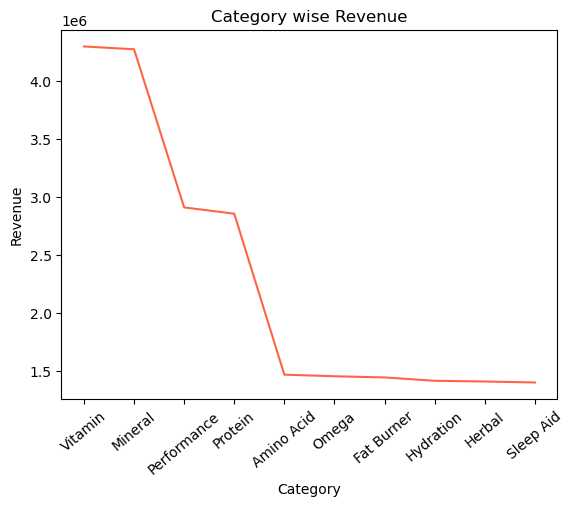

In [43]:
sns.lineplot(x='Category',y='Revenue', data=CR, color='tomato')
plt.title("Category wise Revenue")
plt.xticks(rotation =40)

plt.show()

In [46]:
category_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)


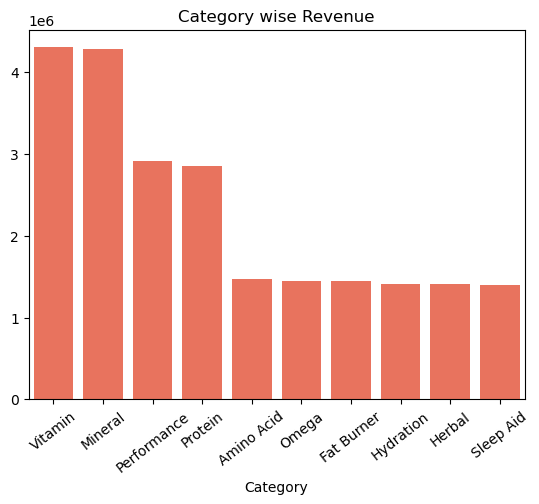

In [51]:
sns.barplot(x=category_revenue.index, y=category_revenue.values, color = 'tomato')
plt.title("Category wise Revenue")
plt.xticks(rotation=38)
plt.show()

In [52]:
df.columns

Index(['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue',
       'Discount', 'Units Returned', 'Location', 'Platform'],
      dtype='object')

In [55]:
lc_plotform = df.groupby(['Location','Platform'])['Revenue'].sum().unstack().fillna(0)

In [56]:
lc_plotform

Platform,Amazon,Walmart,iHerb
Location,,,
Canada,2613844.28,2518639.07,2716096.38
UK,2442671.23,2637066.25,2624222.86
USA,2612936.27,2232862.30,2514941.81


<Figure size 700x400 with 0 Axes>

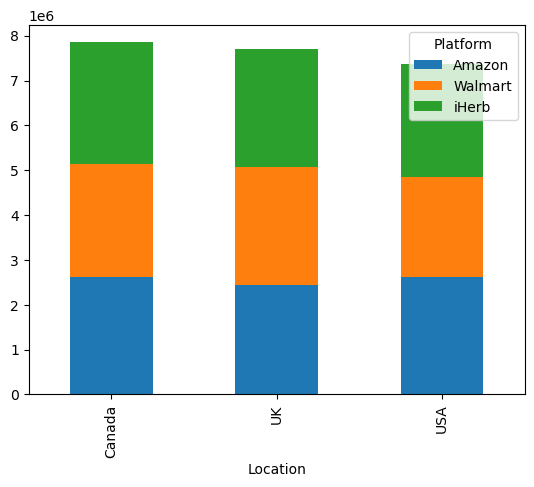

In [62]:
plt.figure(figsize=(7,4))
lc_plotform.plot(kind="bar",stacked=True)
plt.show()

In [63]:
df.columns

Index(['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue',
       'Discount', 'Units Returned', 'Location', 'Platform'],
      dtype='object')

In [66]:
top_5_pr = df.groupby('Product Name')['Revenue'].sum().sort_values(ascending=False).head(5)

In [68]:
top_5_pr

Product Name
Biotin         1486798.62
Zinc           1482546.95
Pre-Workout    1477183.78
BCAA           1464819.63
Fish Oil       1451065.87
Name: Revenue, dtype: float64

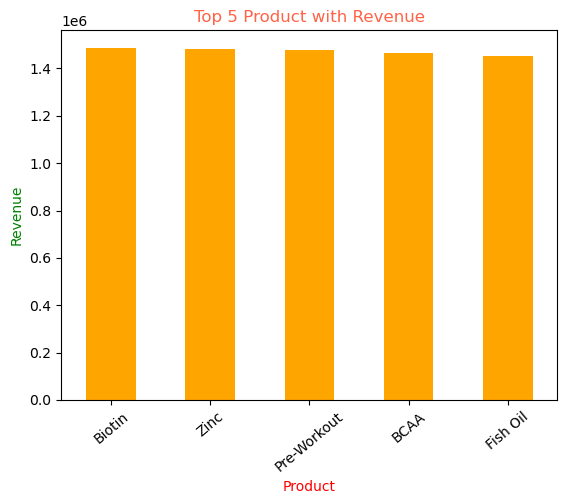

In [71]:
top_5_pr.plot(kind='bar', color='orange')
plt.title("Top 5 Product with Revenue", color='tomato' )
plt.xlabel("Product", color='red')
plt.ylabel("Revenue",color="green")
plt.xticks(rotation=40)


plt.show()

In [75]:
df['ReturnRate'] =  (df['Units Returned']/df['Units Sold'])

In [76]:
df.columns

Index(['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue',
       'Discount', 'Units Returned', 'Location', 'Platform', 'ReturnRate'],
      dtype='object')

In [83]:
pr_retrun = df.groupby('Product Name')['ReturnRate'].sum().sort_values(ascending=False).head(10)

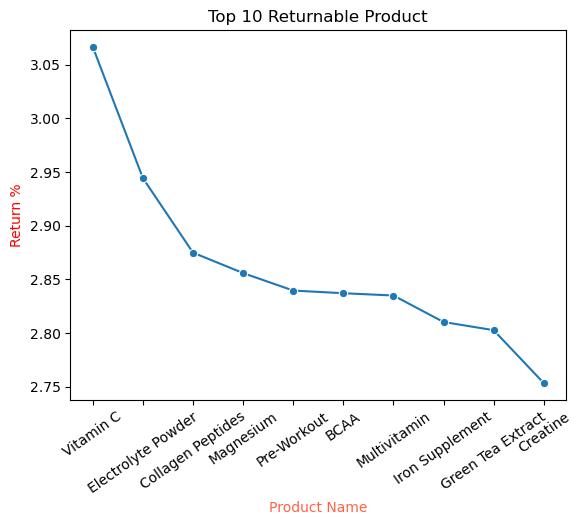

In [88]:
sns.lineplot(x=pr_retrun.index,y=pr_retrun.values,marker='o')
plt.title("Top 10 Returnable Product")
plt.xlabel("Product Name", color="tomato")
plt.ylabel("Return %", color='red')
plt.xticks(rotation=35)
plt.show()

In [92]:
cate_return = df.groupby('Category')['ReturnRate'].sum().sort_values(ascending=False)

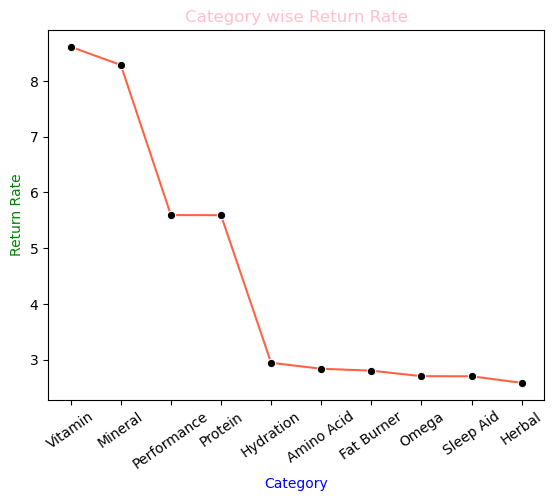

In [98]:
sns.lineplot(x=cate_return.index, y=cate_return.values, color='tomato', marker='o')
plt.gca().lines[0].set_markerfacecolor('black')
plt.title("Category wise Return Rate",color="pink")
plt.xlabel("Category", color="blue")
plt.ylabel("Return Rate", color="green")
plt.xticks(rotation=35)
plt.show()

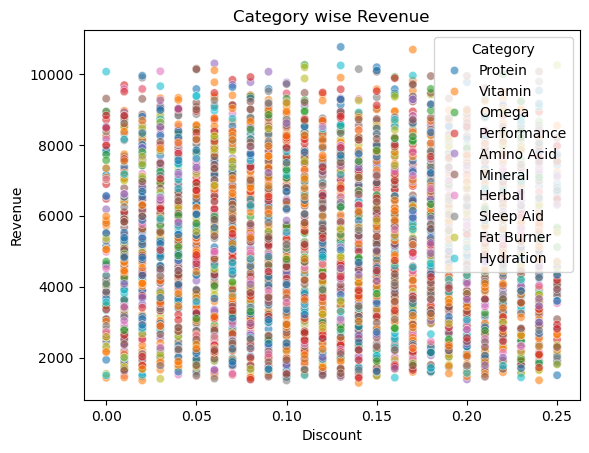

In [100]:
sns.scatterplot(x='Discount', y='Revenue',hue='Category', data=df,alpha = 0.6)
plt.title("Category wise Revenue")
plt.show()

In [101]:
df.columns

Index(['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue',
       'Discount', 'Units Returned', 'Location', 'Platform', 'ReturnRate'],
      dtype='object')

In [103]:
corr = df[['Units Sold','Price','Revenue','Discount','Units Returned']].corr()


In [104]:
corr

,Units Sold,Price,Revenue,Discount,Units Returned
Units Sold,1.000000,0.013749,0.210462,-0.010435,0.116523
Price,0.013749,1.000000,0.977198,-0.008668,-0.010410
Revenue,0.210462,0.977198,1.000000,-0.012531,0.012432
Discount,-0.010435,-0.008668,-0.012531,1.000000,0.004276
Units Returned,0.116523,-0.010410,0.012432,0.004276,1.000000


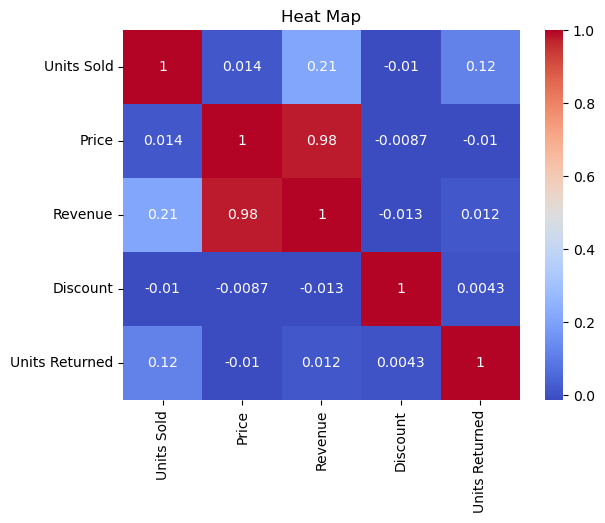

In [105]:
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Heat Map")
plt.show()


In [108]:
fig = px.line(df, x='Date',y='Revenue',color= 'Category',title = 'Revenue by Over Time')
fig.show()

In [109]:
df["Monthly"] = df['Date'].dt.to_period("M")

In [113]:
df.groupby('Monthly').agg({
    "Revenue":"sum",
    "Units Sold":"sum",
    "Discount":"mean",
    "Units Returned":"sum"
}).reset_index()

,Monthly,Revenue,Units Sold,Discount,Units Returned
0,2020-01,290723.89,9547,0.120313,101
1,2020-02,355213.26,9493,0.128125,91
2,2020-03,416547.17,12145,0.111375,123
3,2020-04,326287.92,9605,0.138281,91
4,2020-05,333210.99,9557,0.119375,90
...,...,...,...,...,...
58,2024-11,329894.33,9838,0.117813,106
59,2024-12,446728.99,12042,0.127125,99
60,2025-01,304965.15,9617,0.125156,92
61,2025-02,341768.25,9542,0.128125,103
